## PHASE 1 — DATA LOADING & UNDERSTANDING


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/processed/cleaned_rides.csv')

In [3]:
df.head(10)

,services,date,ride_status,source,destination,duration,ride_id,distance,ride_charge,misc_charge,...,completed,source_cancel_rate,demand_zone,demand_intensity,service_cancel_rate,avg_speed_kmh,fare_per_km,distance_category,duration_category,fare_category
0,cab_economy,2024-07-15,completed,balagere harbor,harohalli nagar,38,RD3161218751875354,9.22,307.71,9.44,...,1,0.1250,high_demand,1.00,0.1074,14.56,34.40,medium,long,premium
1,auto,2024-07-05,completed,basavanagudi 3rd block,bikasipura 1st stage,14,RD8171514284594096,4.29,131.22,1.96,...,1,0.0000,high_demand,0.96,0.1028,18.39,31.04,short,quick,standard
2,auto,2024-07-23,completed,kormangala,kothaguda terrace,22,RD9376481122237926,7.35,141.47,5.52,...,1,0.0986,high_demand,1.05,0.1028,20.05,20.00,medium,moderate,standard
3,cab_economy,2024-06-24,completed,koramangala,kanakapura arc,84,RD3676889143182765,17.48,558.48,1.57,...,1,0.1017,high_demand,1.00,0.1074,12.49,32.04,long,long,premium
4,cab_economy,2024-07-15,completed,ganganagar cove,basaveshwaranagar colony,38,RD6639410275948084,17.63,543.02,9.17,...,1,0.0000,low_demand,0.98,0.1074,27.84,31.32,long,long,premium
5,bike,2024-07-02,completed,hsr layout area,jp nagar viewpoint,16,RD5922205486441934,4.28,66.71,7.71,...,1,0.0000,low_demand,1.01,0.1036,16.05,17.39,short,moderate,budget
6,cab_economy,2024-07-23,completed,arekere heights,dooravani nagar pointe,32,RD9557099396888459,10.37,262.20,0.04,...,1,0.0000,medium_demand,1.00,0.1074,19.44,25.29,medium,long,premium
7,parcel,2024-07-18,completed,electronic city village,ganganagar station,5,RD9473873953525644,1.12,33.92,4.06,...,1,0.0000,medium_demand,1.02,0.1053,13.44,33.91,short,quick,budget
8,bike,2024-08-08,cancelled,mysore road lane,billekahalli 6th block,19,RD1285566012167240,6.43,0.00,0.00,...,0,0.5000,medium_demand,1.02,0.1036,20.31,0.00,medium,moderate,cancelled
9,bike,2024-07-10,completed,kundalahalli alley,rt nagar 5th block,5,RD7238628094142076,2.96,37.17,2.26,...,1,0.2000,medium_demand,1.00,0.1036,35.52,13.32,short,quick,budget


## Data Shape

In [4]:
df.shape

(49801, 30)

## Data Overview

In [5]:
print('===================== Column Names =====================')
print(df.columns.tolist())

print('\n=== Data Types ===')
print(df.dtypes)

print('\n===================== Null Values =====================')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else 'No null values are here')

print('\n===================== Duplicate Rows =====================')
print(f'{df.duplicated().sum()} duplicate rows')

===================== Column Names =====================
['services', 'date', 'ride_status', 'source', 'destination', 'duration', 'ride_id', 'distance', 'ride_charge', 'misc_charge', 'total_fare', 'payment_method', 'timestamp', 'year', 'month', 'hour', 'day_of_week', 'is_weekend', 'peak_hour', 'time_slot', 'completed', 'source_cancel_rate', 'demand_zone', 'demand_intensity', 'service_cancel_rate', 'avg_speed_kmh', 'fare_per_km', 'distance_category', 'duration_category', 'fare_category']

=== Data Types ===
services                   str
date                       str
ride_status                str
source                     str
destination                str
duration                 int64
ride_id                    str
distance               float64
ride_charge            float64
misc_charge            float64
total_fare             float64
payment_method             str
timestamp                  str
year                     int64
month                    int64
hour                   

In [6]:
df.columns

Index(['services', 'date', 'ride_status', 'source', 'destination', 'duration',
       'ride_id', 'distance', 'ride_charge', 'misc_charge', 'total_fare',
       'payment_method', 'timestamp', 'year', 'month', 'hour', 'day_of_week',
       'is_weekend', 'peak_hour', 'time_slot', 'completed',
       'source_cancel_rate', 'demand_zone', 'demand_intensity',
       'service_cancel_rate', 'avg_speed_kmh', 'fare_per_km',
       'distance_category', 'duration_category', 'fare_category'],
      dtype='str')

## PHASE 2 — DATA QUALITY CHECK

In [7]:
df.isnull().sum()

services               0
date                   0
ride_status            0
source                 0
destination            0
duration               0
ride_id                0
distance               0
ride_charge            0
misc_charge            0
total_fare             0
payment_method         0
timestamp              0
year                   0
month                  0
hour                   0
day_of_week            0
is_weekend             0
peak_hour              0
time_slot              0
completed              0
source_cancel_rate     0
demand_zone            0
demand_intensity       0
service_cancel_rate    0
avg_speed_kmh          0
fare_per_km            0
distance_category      0
duration_category      0
fare_category          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## PHASE 3 — DESCRIPTIVE STATISTICS

In [9]:
df.describe()

,duration,distance,ride_charge,misc_charge,total_fare,year,month,hour,day_of_week,is_weekend,peak_hour,completed,source_cancel_rate,demand_intensity,service_cancel_rate,avg_speed_kmh,fare_per_km
count,49801.000000,49801.000000,49801.000000,49801.000000,49801.000000,49801.0,49801.000000,49801.000000,49801.000000,49801.000000,49801.000000,49801.000000,49801.000000,49801.000000,49801.000000,49801.000000,49801.000000
mean,24.089597,6.994316,130.406857,6.898189,137.305046,2024.0,7.037851,11.485412,2.915042,0.262545,0.251059,0.895986,0.104015,0.999559,0.103993,18.312441,20.940385
std,17.569456,5.320823,133.649197,7.462832,134.660971,0.0,0.698329,6.897950,1.979420,0.440022,0.433627,0.305282,0.154618,0.020009,0.002155,6.846936,12.625662
min,5.000000,0.800000,0.000000,0.000000,0.000000,2024.0,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.960000,0.099500,2.070000,0.000000
25%,12.000000,3.310000,45.830000,1.630000,53.090000,2024.0,7.000000,6.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.990000,0.102800,13.260000,12.860000
50%,19.000000,5.480000,85.950000,5.460000,93.840000,2024.0,7.000000,11.000000,3.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.103600,17.690000,19.850000
75%,31.000000,9.020000,174.470000,9.230000,182.170000,2024.0,8.000000,17.000000,5.000000,1.000000,1.000000,1.000000,0.200000,1.010000,0.105300,22.300000,27.960000
max,120.000000,45.000000,1291.910000,50.000000,1301.580000,2024.0,8.000000,23.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.050000,0.107400,73.100000,110.180000


In [10]:
num_cols = ['ride_charge', 'distance', 'duration', 'avg_speed_kmh', 'fare_per_km', 'misc_charge']

for col in num_cols:
    print(f"\n--- {col} ---")
    print(f"  Mean   : {df[col].mean():.2f}")
    print(f"  Median : {df[col].median():.2f}")
    print(f"  Mode   : {df[col].mode()[0]:.2f}")
    print(f"  Std Dev: {df[col].std():.2f}")
    print(f"  Min    : {df[col].min():.2f}")
    print(f"  Max    : {df[col].max():.2f}")


--- ride_charge ---
  Mean   : 130.41
  Median : 85.95
  Mode   : 0.00
  Std Dev: 133.65
  Min    : 0.00
  Max    : 1291.91

--- distance ---
  Mean   : 6.99
  Median : 5.48
  Mode   : 1.00
  Std Dev: 5.32
  Min    : 0.80
  Max    : 45.00

--- duration ---
  Mean   : 24.09
  Median : 19.00
  Mode   : 5.00
  Std Dev: 17.57
  Min    : 5.00
  Max    : 120.00

--- avg_speed_kmh ---
  Mean   : 18.31
  Median : 17.69
  Mode   : 12.00
  Std Dev: 6.85
  Min    : 2.07
  Max    : 73.10

--- fare_per_km ---
  Mean   : 20.94
  Median : 19.85
  Mode   : 0.00
  Std Dev: 12.63
  Min    : 0.00
  Max    : 110.18

--- misc_charge ---
  Mean   : 6.90
  Median : 5.46
  Mode   : 0.00
  Std Dev: 7.46
  Min    : 0.00
  Max    : 50.00


## Separate completed vs cancelled rides

In [11]:
completed = df[df['ride_status'] == 'completed'].copy()
cancelled = df[df['ride_status'] == 'cancelled'].copy()

print(f"Completed : {len(completed)} rides ({len(completed)/len(df)*100:.1f}%)")
print(f"Cancelled : {len(cancelled)} rides ({len(cancelled)/len(df)*100:.1f}%)")

Completed : 44621 rides (89.6%)
Cancelled : 5180 rides (10.4%)


## Visualization: Distributions (histograms)

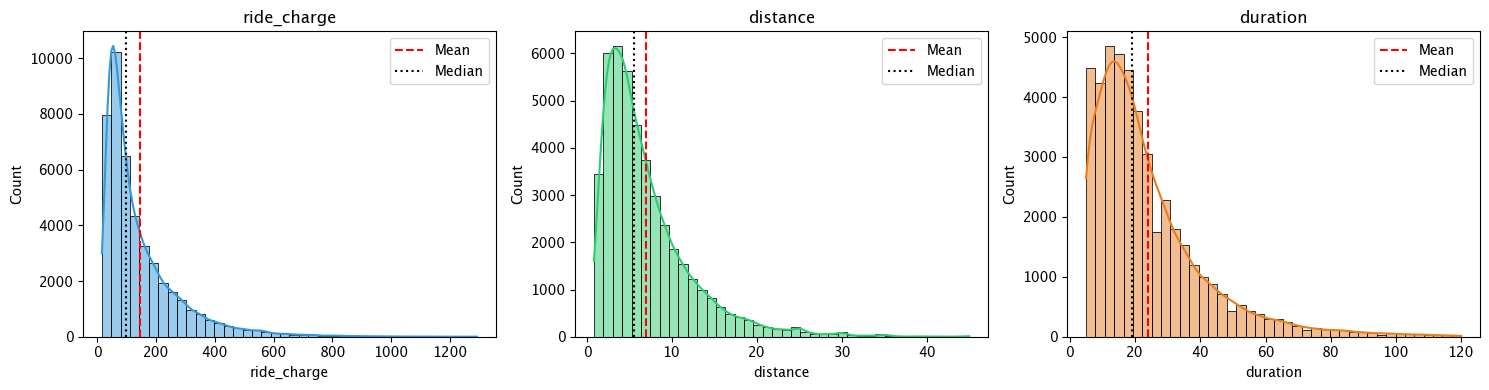

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes,
    ['ride_charge', 'distance', 'duration'],
    ['#3498db', '#2ecc71', '#e67e22']):

    sns.histplot(completed[col], bins=40, kde=True, ax=ax, color=color)
    ax.axvline(completed[col].mean(), color='red', linestyle='--', label='Mean')
    ax.axvline(completed[col].median(), color='black', linestyle=':', label='Median')
    ax.legend()
    ax.set_title(col)

plt.tight_layout()
plt.show()

## PHASE 4 — UNIVARIATE ANALYSIS

### U1 — Numeric variables


In [13]:
num_cols = ['ride_charge', 'misc_charge', 'distance', 'duration',
            'avg_speed_kmh', 'fare_per_km', 'demand_intensity',
            'source_cancel_rate', 'service_cancel_rate']

stats = []
for col in num_cols:
    stats.append({
        'column'   : col,
        'mean'     : df[col].mean(),
        'median'   : df[col].median(),
        'mode'     : df[col].mode()[0],
        'std'      : df[col].std(),
        'variance' : df[col].var(),
        'min'      : df[col].min(),
        'max'      : df[col].max(),
        'range'    : df[col].max() - df[col].min(),
        'Q1'       : df[col].quantile(0.25),
        'Q3'       : df[col].quantile(0.75),
        'IQR'      : df[col].quantile(0.75) - df[col].quantile(0.25),
        'skewness' : df[col].skew(),
        'kurtosis' : df[col].kurt(),
    })

stats_df = pd.DataFrame(stats).set_index('column').round(3)
print(stats_df)

                        mean  median    mode      std   variance   min  \
column                                                                   
ride_charge          130.407  85.950   0.000  133.649  17862.108  0.00   
misc_charge            6.898   5.460   0.000    7.463     55.694  0.00   
distance               6.994   5.480   1.000    5.321     28.311  0.80   
duration              24.090  19.000   5.000   17.569    308.686  5.00   
avg_speed_kmh         18.312  17.690  12.000    6.847     46.881  2.07   
fare_per_km           20.940  19.850   0.000   12.626    159.407  0.00   
demand_intensity       1.000   1.000   1.000    0.020      0.000  0.96   
source_cancel_rate     0.104   0.000   0.000    0.155      0.024  0.00   
service_cancel_rate    0.104   0.104   0.104    0.002      0.000  0.10   

                          max     range      Q1       Q3      IQR  skewness  \
column                                                                        
ride_charge          1291.9

### U2 — Histograms with KDE for all numeric columns


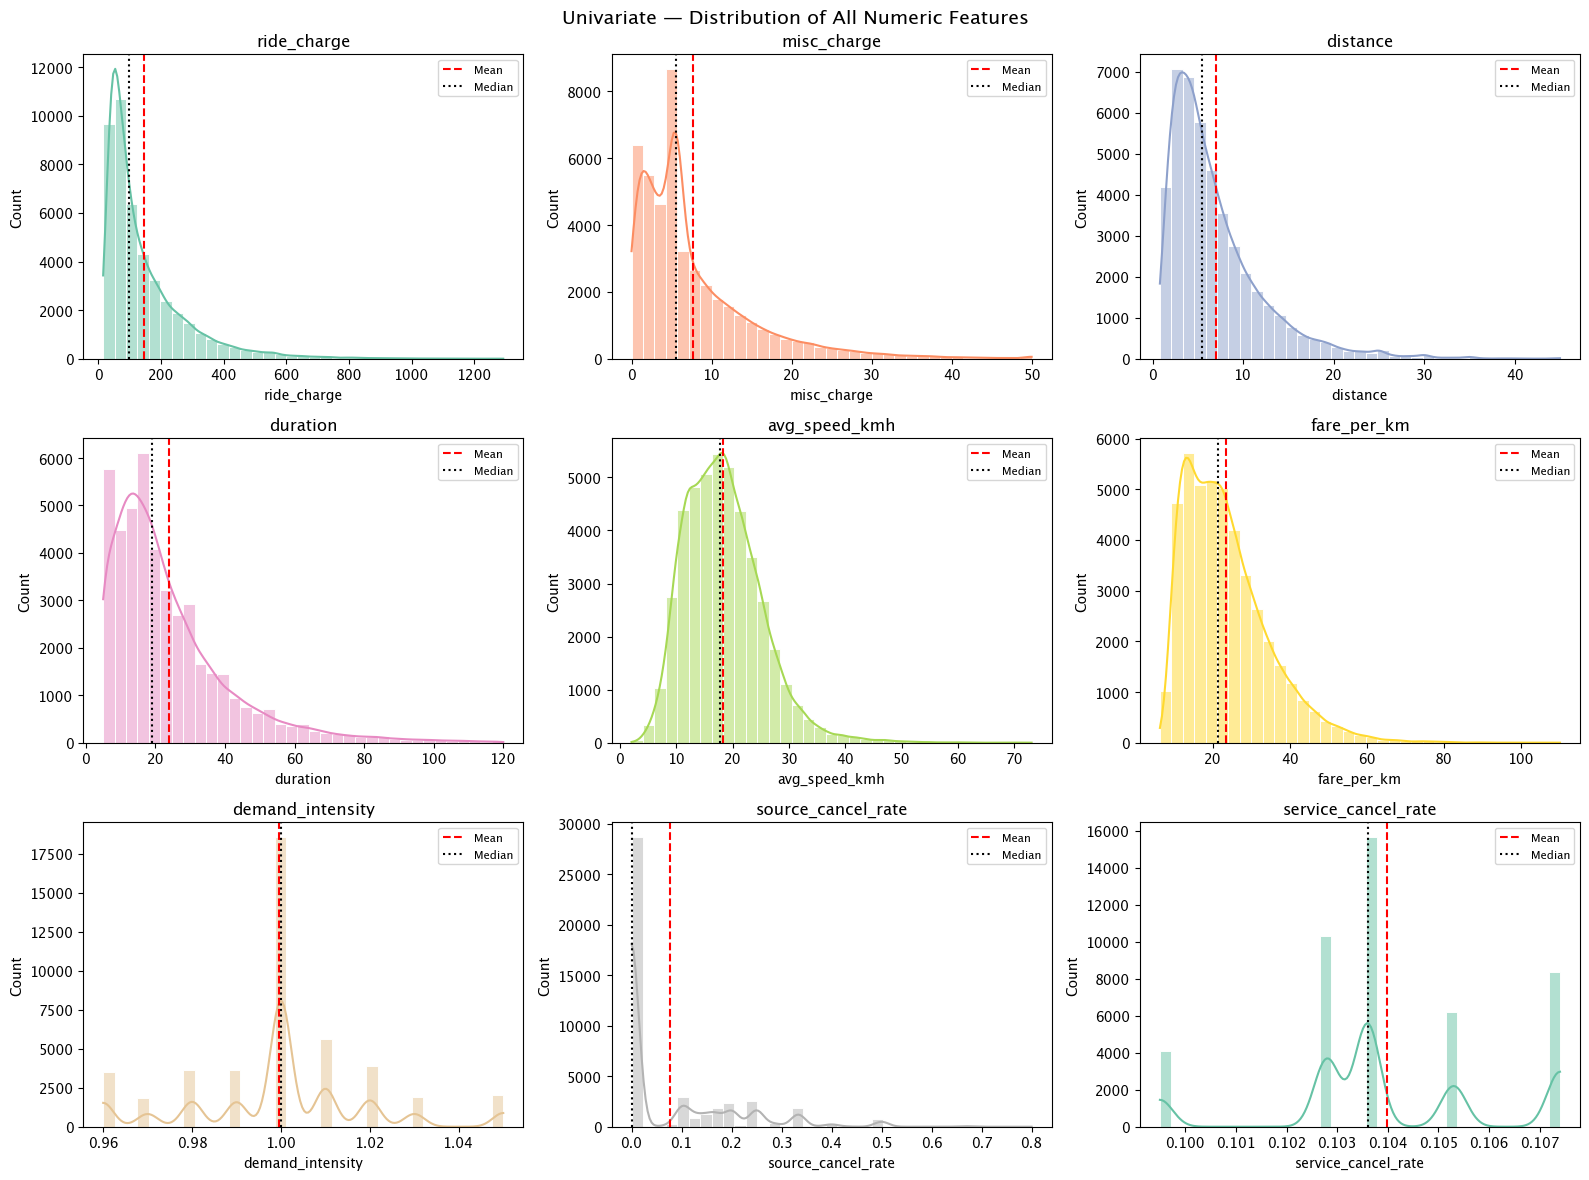

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(completed[col], bins=35, kde=True, ax=axes[i],
                 color=sns.color_palette('Set2')[i % 8], edgecolor='white')
    axes[i].axvline(completed[col].mean(),   color='red',   linestyle='--', lw=1.5, label='Mean')
    axes[i].axvline(completed[col].median(), color='black', linestyle=':',  lw=1.5, label='Median')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Univariate — Distribution of All Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### U3 — Boxplots for outlier detection


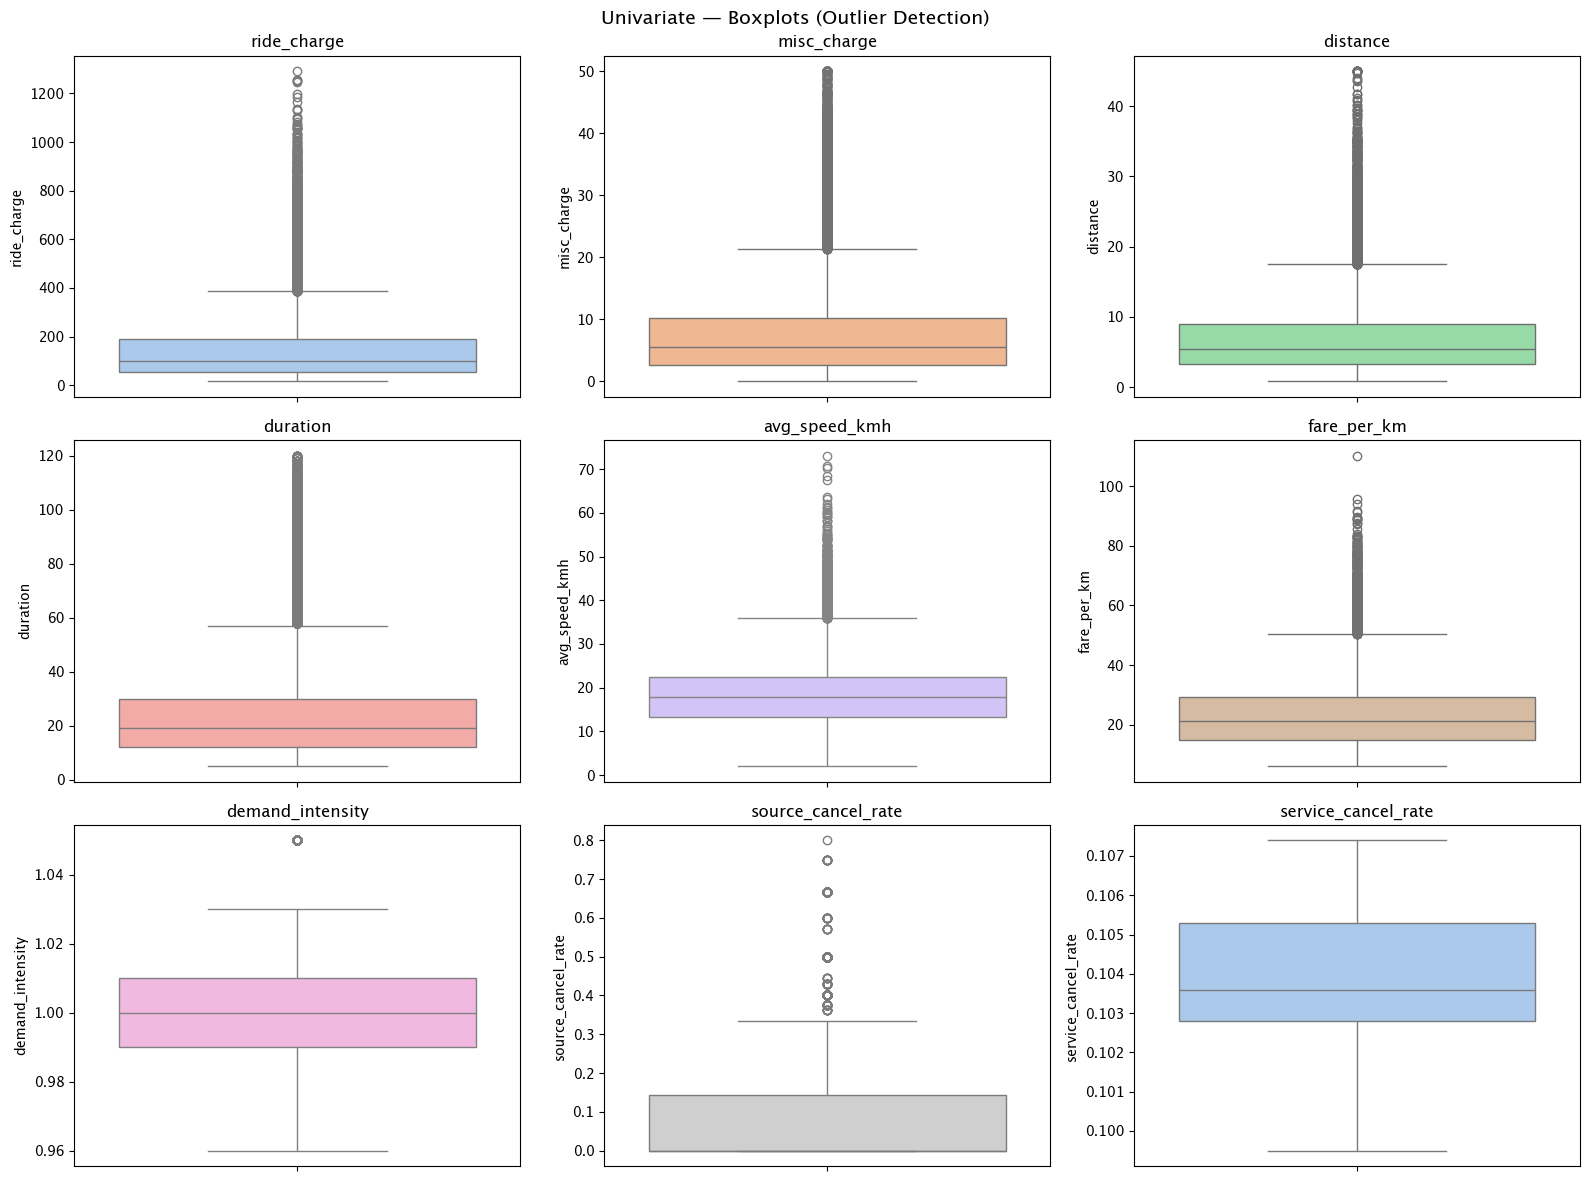

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=completed[col], ax=axes[i],
                color=sns.color_palette('pastel')[i % 8])
    axes[i].set_title(col, fontweight='bold')

plt.suptitle('Univariate — Boxplots (Outlier Detection)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### U4 — Outlier count using IQR method


In [16]:
print("=== Outlier Count per Column (IQR method) ===")
for col in num_cols:
    Q1  = completed[col].quantile(0.25)
    Q3  = completed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = completed[(completed[col] < lower) | (completed[col] > upper)]
    print(f"{col:30s}: {len(outliers)} outliers ({len(outliers)/len(completed)*100:.2f}%)")

=== Outlier Count per Column (IQR method) ===
ride_charge                   : 2681 outliers (6.01%)
misc_charge                   : 2766 outliers (6.20%)
distance                      : 2221 outliers (4.98%)
duration                      : 2409 outliers (5.40%)
avg_speed_kmh                 : 738 outliers (1.65%)
fare_per_km                   : 1096 outliers (2.46%)
demand_intensity              : 2017 outliers (4.52%)
source_cancel_rate            : 1312 outliers (2.94%)
service_cancel_rate           : 0 outliers (0.00%)


### U5 — Categorical variables (count + percentage)


In [17]:
cat_cols = ['services', 'ride_status', 'fare_category',
            'distance_category', 'duration_category', 'demand_zone', 'demand_intensity']

for col in cat_cols:
    print(f"\n{'='*40}")
    print(f"  {col}")
    print(f"{'='*40}")
    vc = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    result = pd.DataFrame({'count': vc, 'percentage': pct.round(2)})
    print(result)



  services
             count  percentage
services                      
bike         17492       35.12
auto         11474       23.04
cab_economy   9370       18.81
parcel        6924       13.90
bike_lite     4541        9.12

  ride_status
             count  percentage
ride_status                   
completed    44621        89.6
cancelled     5180        10.4

  fare_category
               count  percentage
fare_category                   
premium        15171       30.46
standard       14725       29.57
budget         14725       29.57
cancelled       5180       10.40

  distance_category
                   count  percentage
distance_category                   
medium             23294       46.77
short              22535       45.25
long                3972        7.98

  duration_category
                   count  percentage
duration_category                   
moderate           18659       37.47
quick              18651       37.45
long               12491       25.08

  de

### U6 — Bar charts for all categorical columns


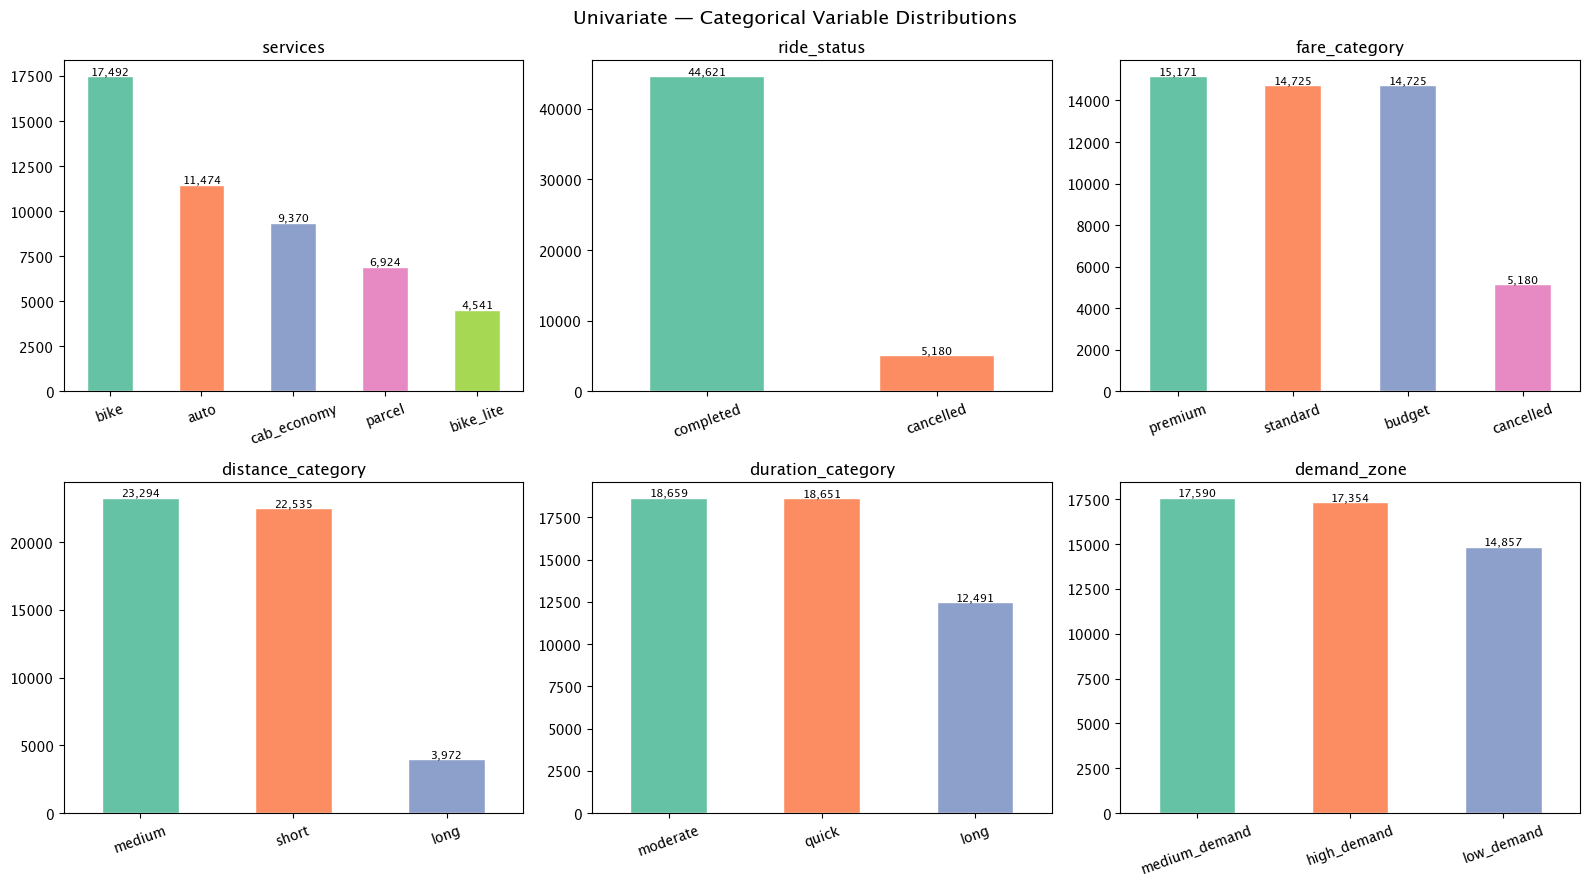

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:6]):
    vc = df[col].value_counts()
    vc.plot(kind='bar', ax=axes[i],
            color=sns.color_palette('Set2', len(vc)), edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height()):,}',
                         (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=8)

plt.suptitle('Univariate — Categorical Variable Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### U7 — Pie charts for key categorical columns


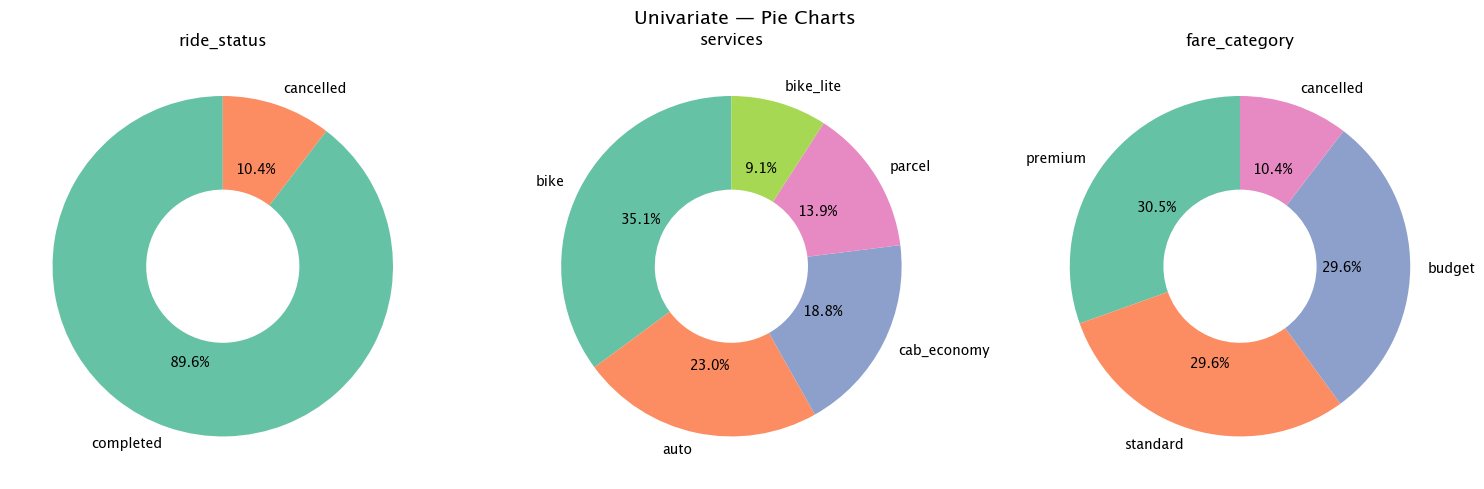

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['ride_status', 'services', 'fare_category']):
    vc = df[col].value_counts()
    ax.pie(vc, labels=vc.index, autopct='%1.1f%%',
           colors=sns.color_palette('Set2', len(vc)),
           startangle=90, wedgeprops=dict(width=0.55))
    ax.set_title(col, fontweight='bold')

plt.suptitle('Univariate — Pie Charts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## BIVARIATE ANALYSIS


### B1 — Numeric vs Numeric (scatter plots)


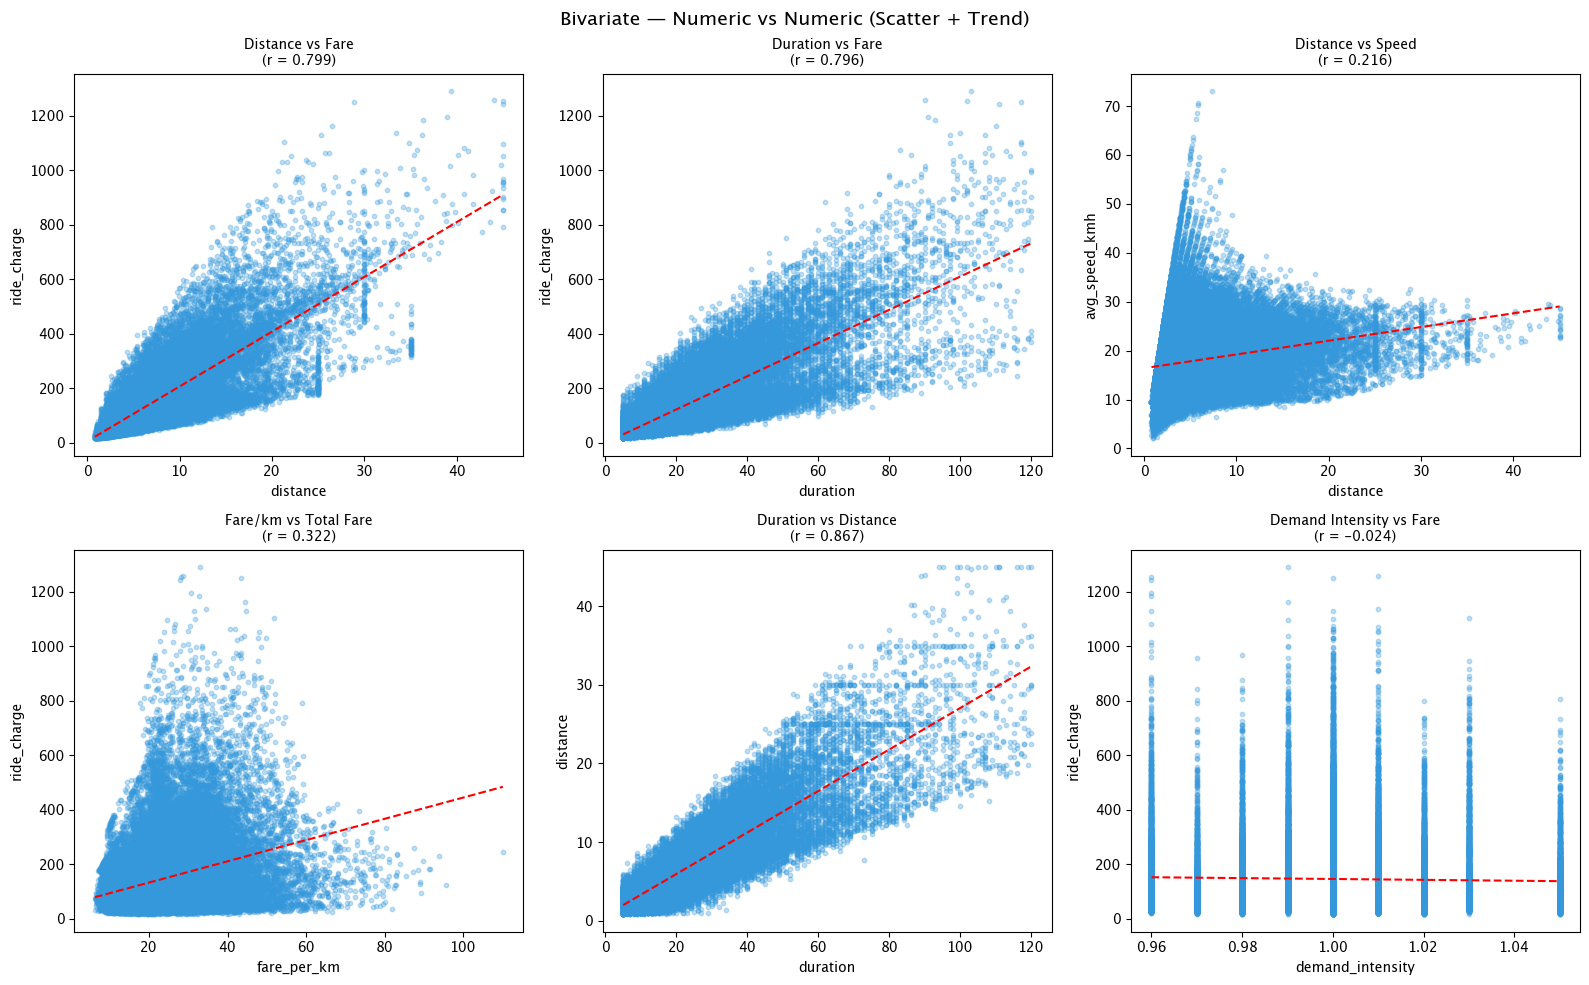

In [20]:
pairs = [
    ('distance',    'ride_charge',    'Distance vs Fare'),
    ('duration',    'ride_charge',    'Duration vs Fare'),
    ('distance',    'avg_speed_kmh',  'Distance vs Speed'),
    ('fare_per_km', 'ride_charge',    'Fare/km vs Total Fare'),
    ('duration',    'distance',       'Duration vs Distance'),
    ('demand_intensity', 'ride_charge','Demand Intensity vs Fare'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(completed[x], completed[y], alpha=0.3, s=10, color='#3498db')

    # Trend line
    m, b = np.polyfit(completed[x], completed[y], 1)
    ax.plot(sorted(completed[x]), [m*xi + b for xi in sorted(completed[x])],
            color='red', lw=1.5, linestyle='--')

    corr_val = completed[x].corr(completed[y])
    ax.set_title(f'{title}\n(r = {corr_val:.3f})', fontweight='bold', fontsize=10)
    ax.set_xlabel(x)
    ax.set_ylabel(y)

plt.suptitle('Bivariate — Numeric vs Numeric (Scatter + Trend)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### B2 — Numeric vs Categorical (boxplots)



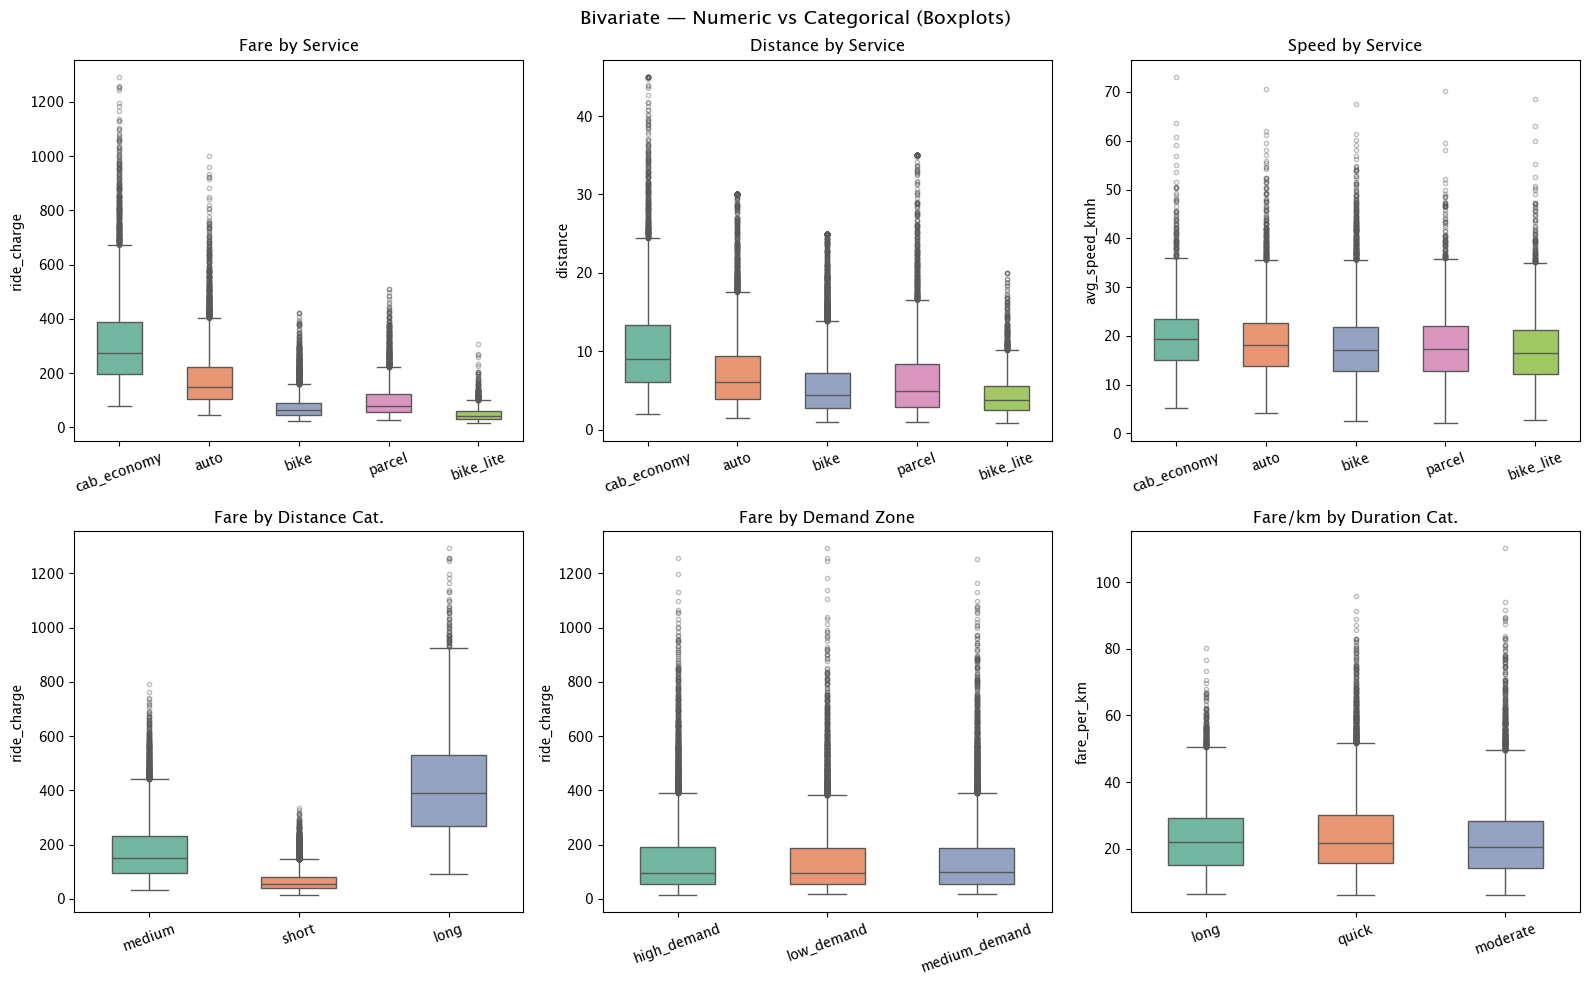

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

combos = [
    ('services',           'ride_charge',   'Fare by Service'),
    ('services',           'distance',      'Distance by Service'),
    ('services',           'avg_speed_kmh', 'Speed by Service'),
    ('distance_category',  'ride_charge',   'Fare by Distance Cat.'),
    ('demand_zone',        'ride_charge',   'Fare by Demand Zone'),
    ('duration_category',  'fare_per_km',   'Fare/km by Duration Cat.'),
]

for ax, (cat, num, title) in zip(axes, combos):
    sns.boxplot(data=completed, x=cat, y=num,
                palette='Set2', ax=ax, width=0.5,
                flierprops={'marker':'o','markersize':3,'alpha':0.4})
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.set_xlabel('')

plt.suptitle('Bivariate — Numeric vs Categorical (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### B3 — Numeric vs Categorical (violin plots — shows shape too)


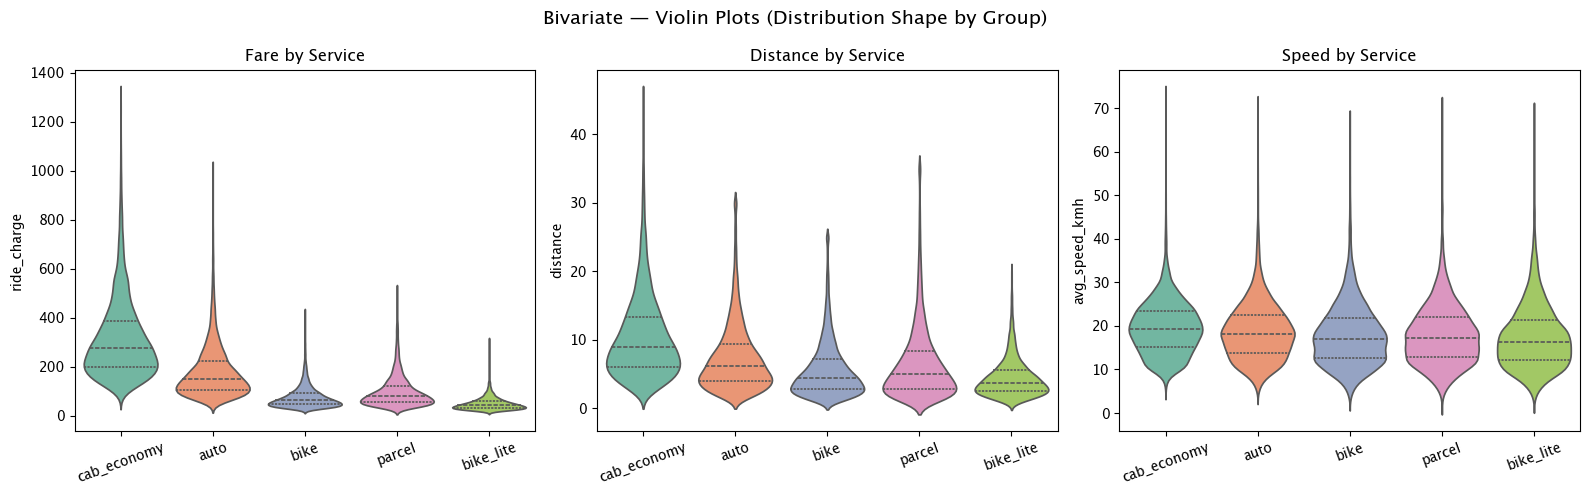

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (cat, num, title) in zip(axes, combos[:3]):
    sns.violinplot(data=completed, x=cat, y=num,
                   palette='Set2', ax=ax, inner='quartile')
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.set_xlabel('')

plt.suptitle('Bivariate — Violin Plots (Distribution Shape by Group)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### B4 — Numeric vs Categorical (grouped bar — mean comparison)


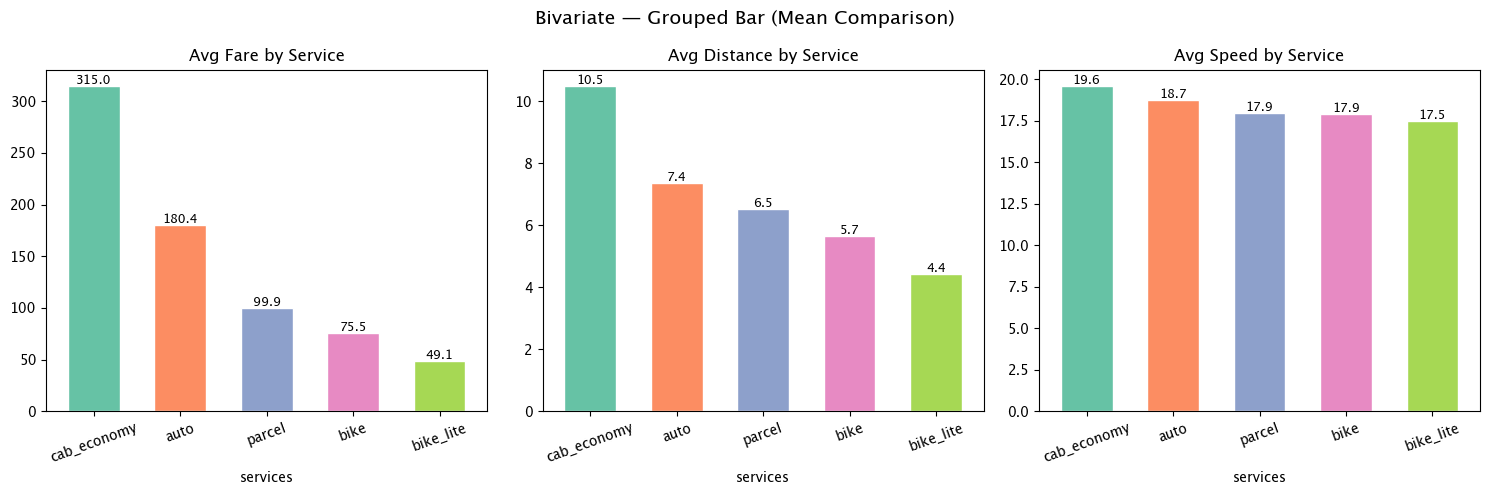

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (cat, num, title) in zip(axes, combos[:3]):
    grp = completed.groupby(cat)[num].mean().sort_values(ascending=False)
    grp.plot(kind='bar', ax=ax,
             color=sns.color_palette('Set2', len(grp)), edgecolor='white', width=0.6)
    ax.set_title(f'Avg {title}', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Bivariate — Grouped Bar (Mean Comparison)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### B5 — Categorical vs Categorical (crosstab + heatmap)


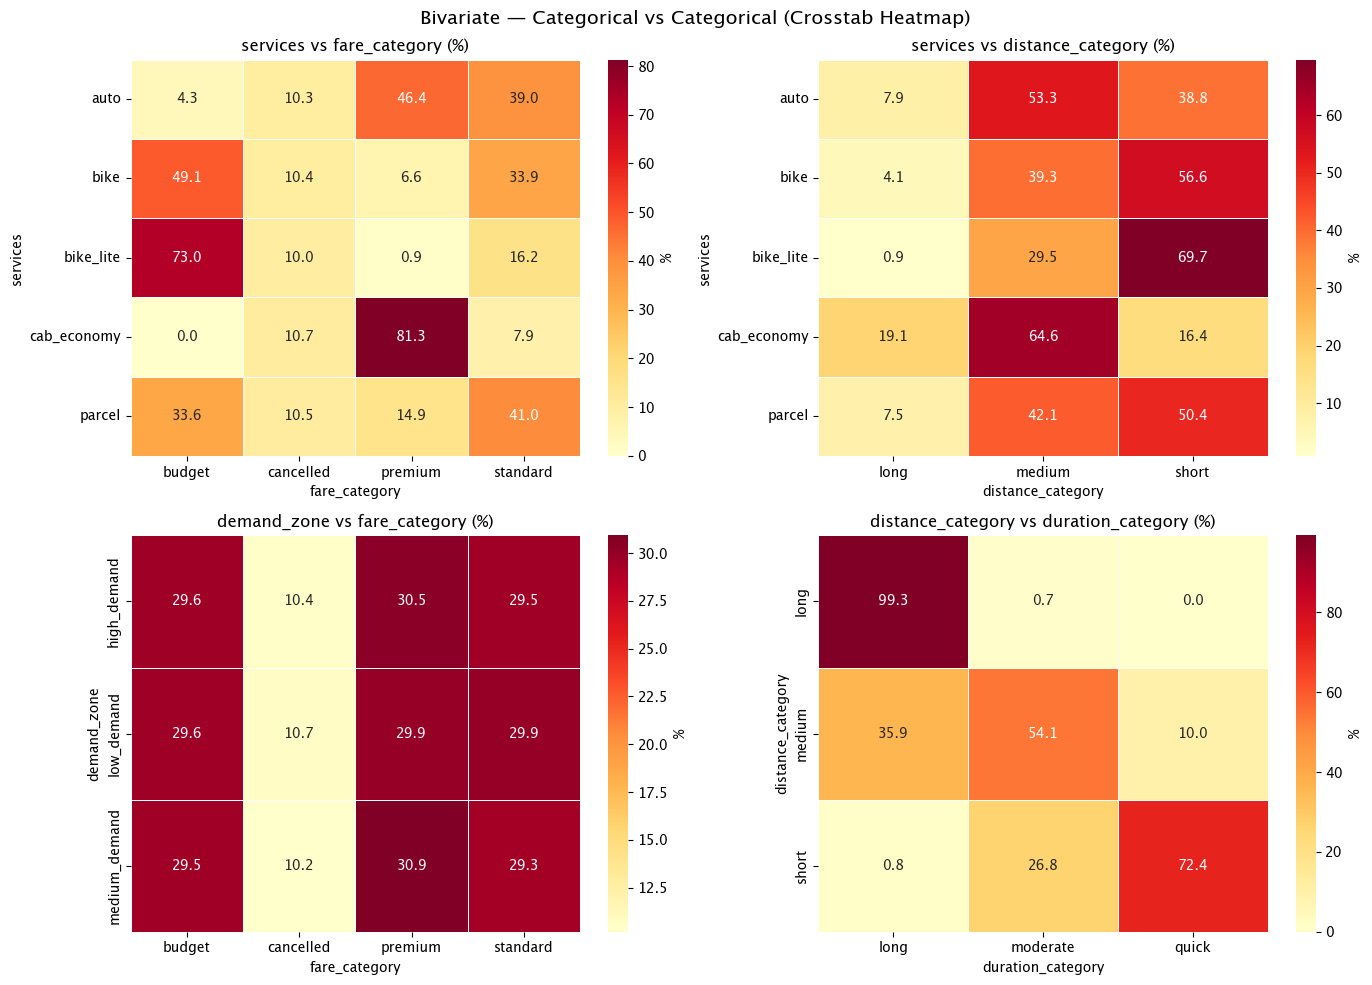

In [24]:
# All combinations of categorical pairs
cat_pairs = [
    ('services',          'fare_category'),
    ('services',          'distance_category'),
    ('demand_zone',       'fare_category'),
    ('distance_category', 'duration_category'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (c1, c2) in zip(axes, cat_pairs):
    ct = pd.crosstab(df[c1], df[c2], normalize='index') * 100
    sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': '%'})
    ax.set_title(f'{c1} vs {c2} (%)', fontweight='bold')

plt.suptitle('Bivariate — Categorical vs Categorical (Crosstab Heatmap)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### B6 — Cancellation rate by service (bivariate: service × status)


      services  cancel_rate_%
0  cab_economy      10.736393
1       parcel      10.528596
2         bike      10.364738
3         auto      10.284121
4    bike_lite       9.953755


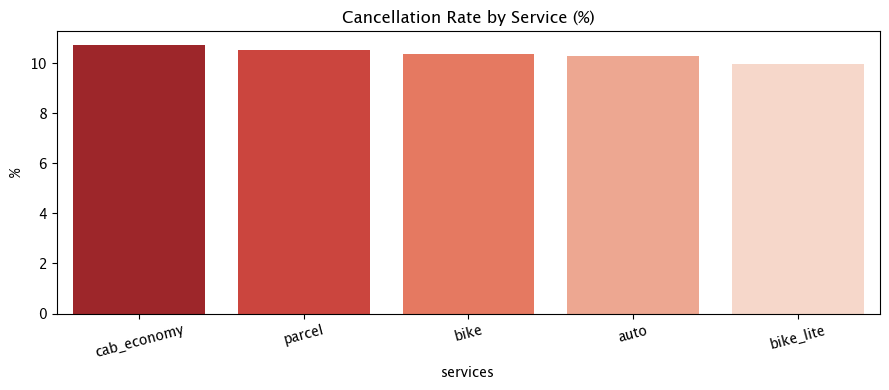

In [25]:
cancel_rate = df.groupby('services').apply(
    lambda x: (x['ride_status'] == 'cancelled').sum() / len(x) * 100
).sort_values(ascending=False).reset_index()
cancel_rate.columns = ['services', 'cancel_rate_%']

print(cancel_rate)

plt.figure(figsize=(9, 4))
sns.barplot(data=cancel_rate, x='services', y='cancel_rate_%',
            palette='Reds_r')
plt.title('Cancellation Rate by Service (%)', fontweight='bold')
plt.ylabel('%')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 📊 Business Insight — Cancellation Rate by Service
High cancellation rates on certain services indicate a supply-demand mismatch specific to that ride type.
Services with higher cancellation rates should be prioritised for driver incentive schemes.
A difference of even 2–3 percentage points translates to hundreds of lost rides per month at this volume.

### B7 — Time bivariate: monthly rides by service


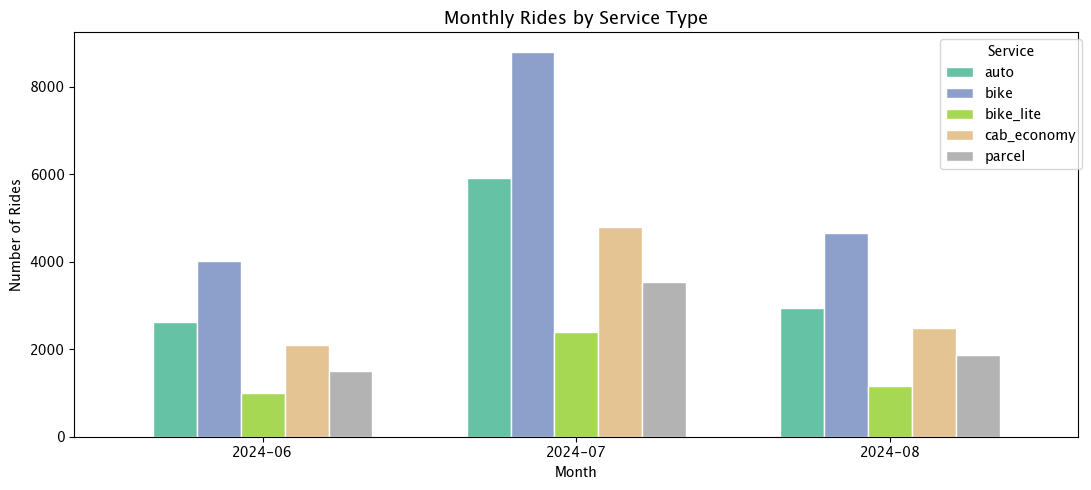

In [26]:
df['month'] = pd.to_datetime(df['date']).dt.to_period('M').astype(str)

monthly_service = df.groupby(['month', 'services'])['ride_id'].count().unstack()

monthly_service.plot(kind='bar', figsize=(11, 5), colormap='Set2',
                     edgecolor='white', width=0.7)
plt.title('Monthly Rides by Service Type', fontweight='bold', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.xticks(rotation=0)
plt.legend(title='Service', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

## MULTIVARIATE ANALYSIS


### M1 — Correlation heatmap (all numeric at once)


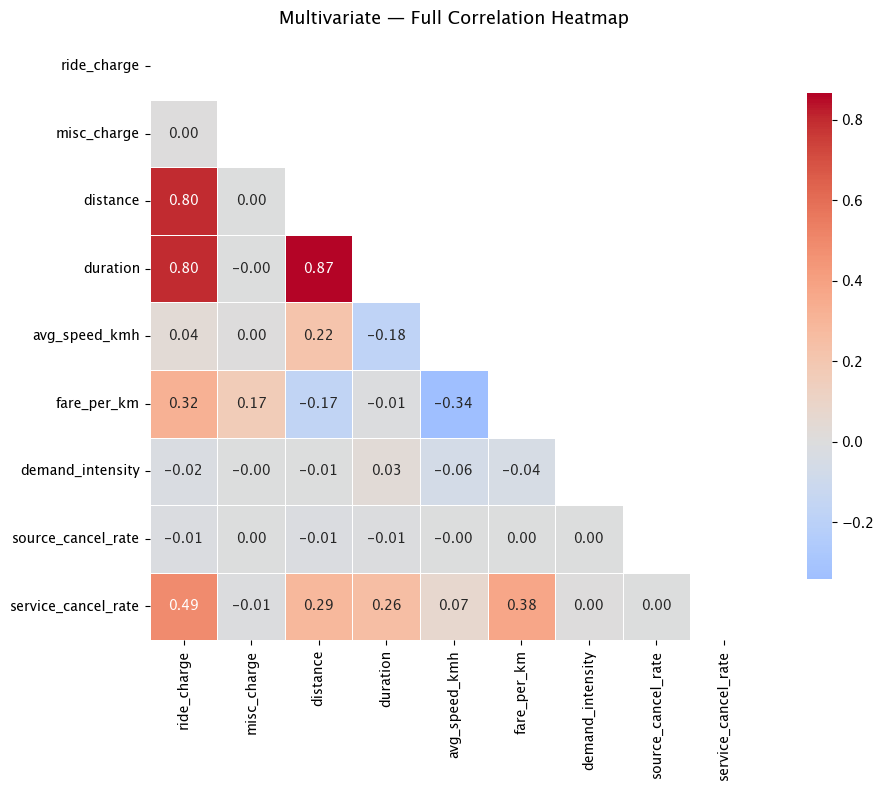

In [27]:
num_cols = ['ride_charge', 'misc_charge', 'distance', 'duration',
            'avg_speed_kmh', 'fare_per_km', 'demand_intensity',
            'source_cancel_rate', 'service_cancel_rate']

corr = completed[num_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show only lower triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Multivariate — Full Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Business Insight — Correlation Heatmap
Distance and fare are strongly correlated (r ≈ 0.9), confirming Rapido's pricing is distance-linear.
Duration adds incremental value but is not independently priced.
Demand intensity shows near-zero correlation with fare — Rapido is not surge pricing during peak demand,
which represents an untapped revenue lever.

### M2 — Pair plot (scatter matrix — all numeric pairs at once)


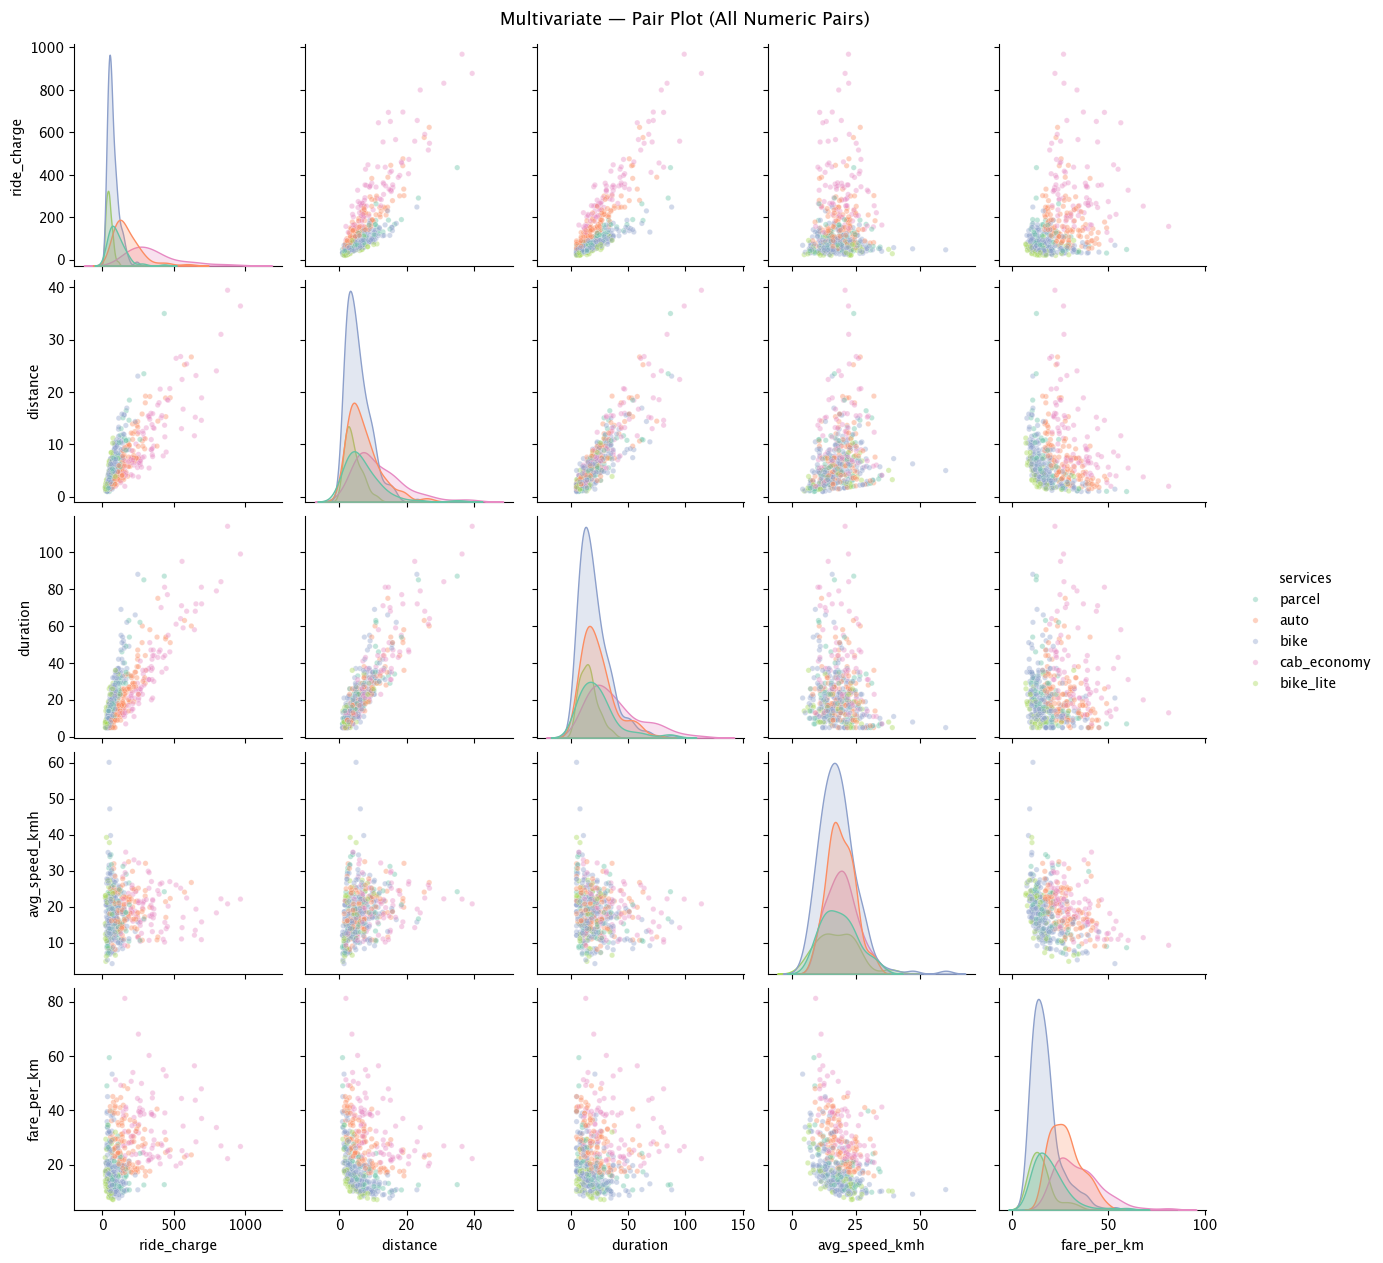

In [28]:
cols_for_pair = ['ride_charge', 'distance', 'duration', 'avg_speed_kmh', 'fare_per_km']

pair_df = completed[cols_for_pair + ['services']].sample(500)  # sample for speed

sns.pairplot(pair_df, hue='services', palette='Set2',
             plot_kws={'alpha': 0.4, 's': 15},
             diag_kind='kde')
plt.suptitle('Multivariate — Pair Plot (All Numeric Pairs)', y=1.01,
             fontsize=13, fontweight='bold')
plt.show()

### M3 — Scatter with color + size (3 numeric + 1 categorical)


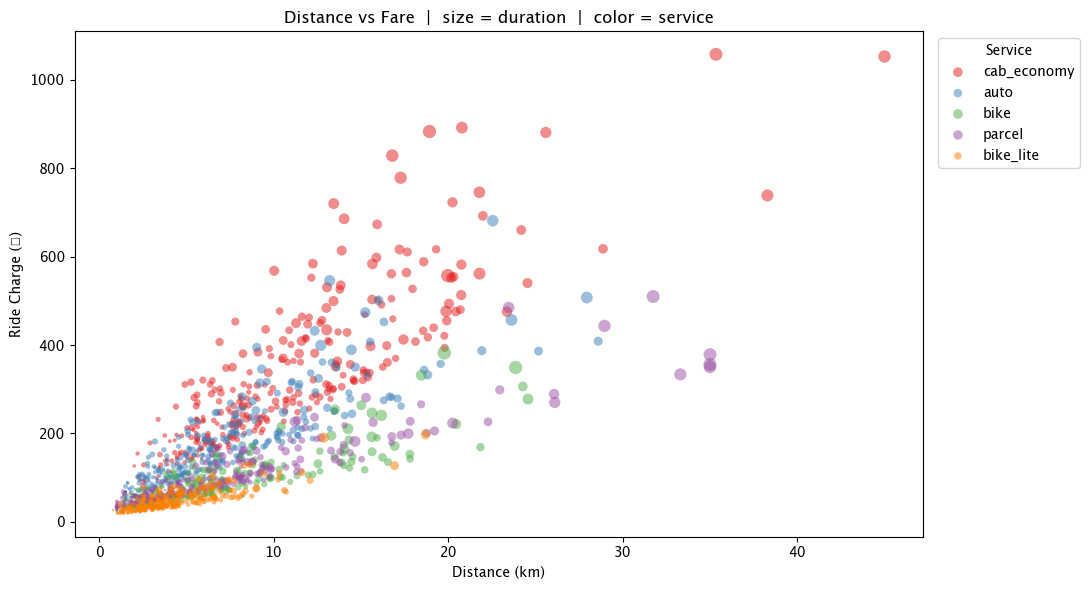

In [29]:
plt.figure(figsize=(11, 6))

services_list = completed['services'].unique()
palette = sns.color_palette('Set1', len(services_list))
color_map = dict(zip(services_list, palette))

for svc in services_list:
    sub = completed[completed['services'] == svc].sample(min(300, len(completed[completed['services']==svc])))
    plt.scatter(sub['distance'], sub['ride_charge'],
                s=sub['duration'] * 0.8,        # size = duration
                c=[color_map[svc]],
                alpha=0.5, label=svc, edgecolors='none')

plt.title('Distance vs Fare  |  size = duration  |  color = service',
          fontweight='bold', fontsize=12)
plt.xlabel('Distance (km)')
plt.ylabel('Ride Charge (₹)')
plt.legend(title='Service', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

### M4 — Grouped boxplot (numeric + 2 categoricals)


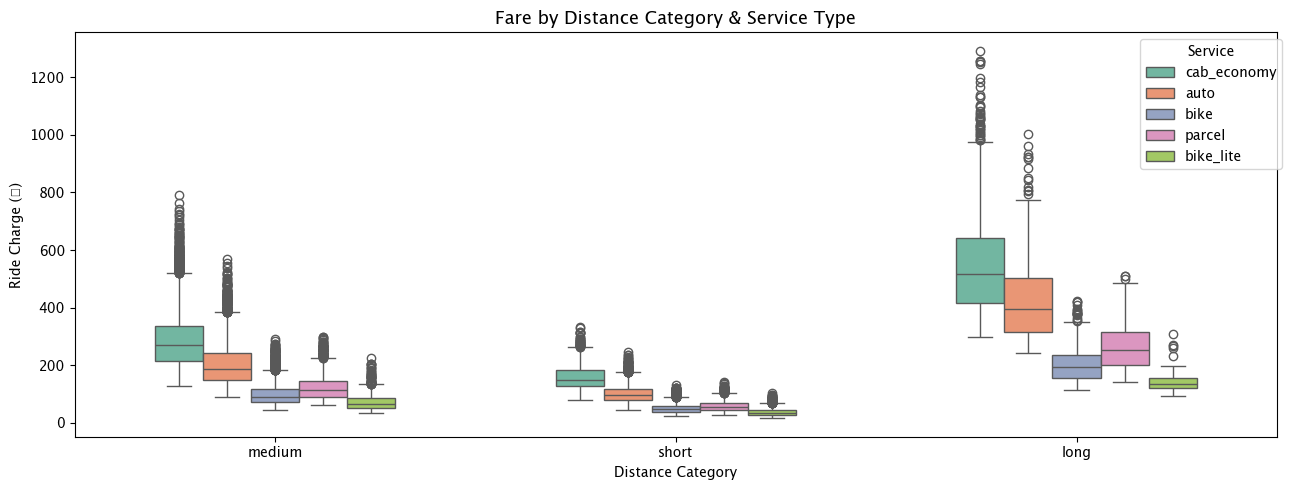

In [30]:
plt.figure(figsize=(13, 5))
sns.boxplot(data=completed, x='distance_category', y='ride_charge',
            hue='services', palette='Set2', width=0.6)
plt.title('Fare by Distance Category & Service Type', fontweight='bold', fontsize=13)
plt.xlabel('Distance Category')
plt.ylabel('Ride Charge (₹)')
plt.legend(title='Service', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

## M5 — Facet grid (same chart, split by category)


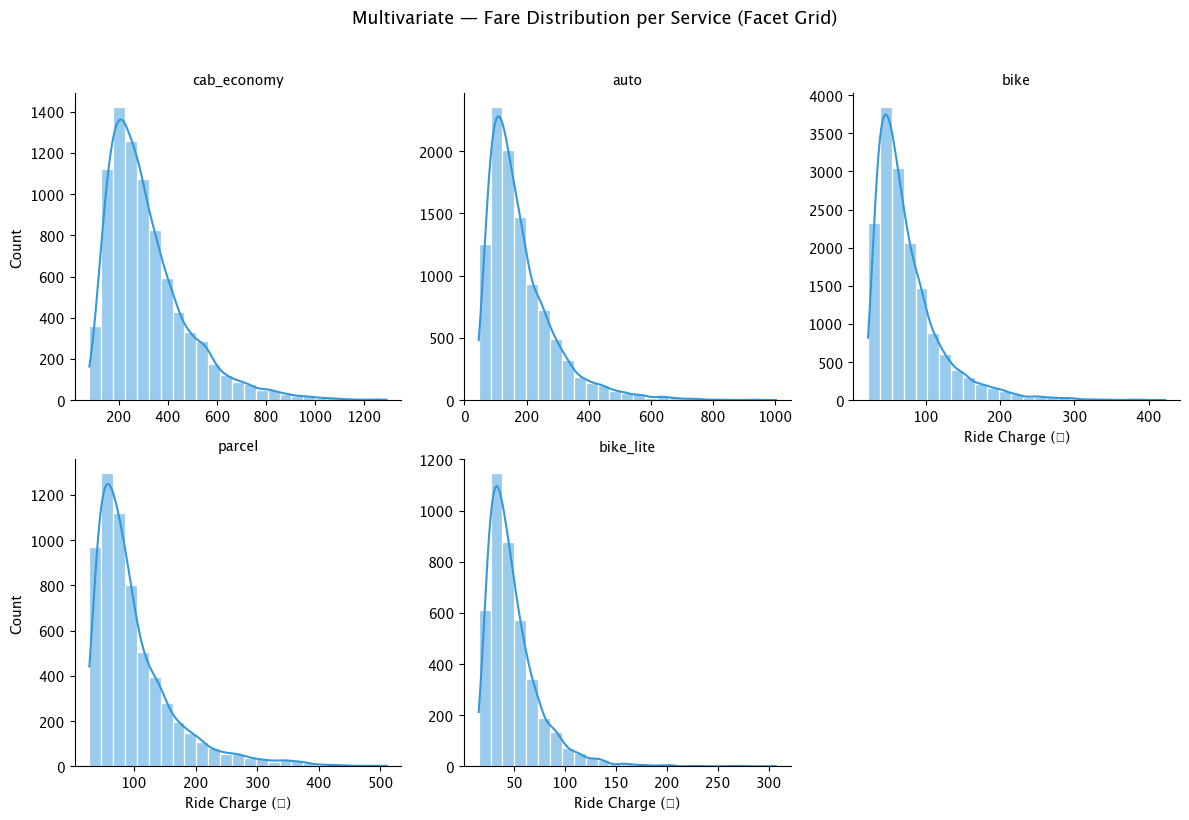

In [31]:
g = sns.FacetGrid(completed, col='services', col_wrap=3,
                  height=4, sharey=False, sharex=False)
g.map_dataframe(sns.histplot, x='ride_charge', bins=25, kde=True,
                color='#3498db', edgecolor='white')
g.set_titles(col_template='{col_name}', fontweight='bold')
g.set_axis_labels('Ride Charge (₹)', 'Count')
g.figure.suptitle('Multivariate — Fare Distribution per Service (Facet Grid)',
                   fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### M6 — Heatmap: avg fare across 2 categories


services            auto   bike  bike_lite  cab_economy  parcel
distance_category                                              
long               425.0  204.0      151.0        551.0   264.0
medium             202.0   98.0       72.0        287.0   122.0
short              102.0   50.0       38.0        157.0    58.0


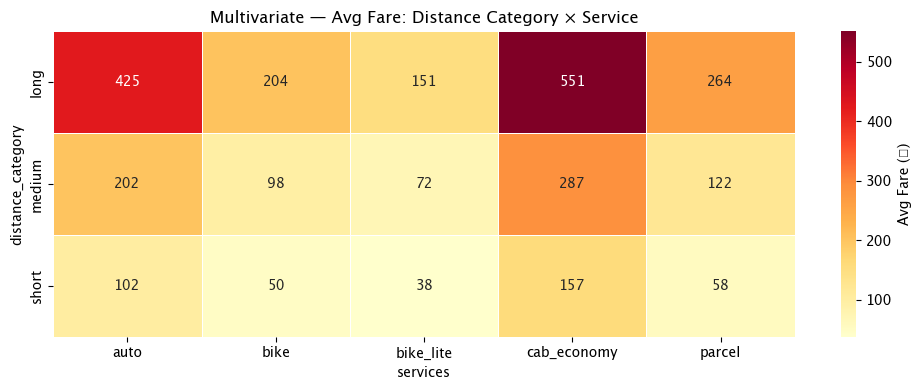

In [32]:
pivot = completed.pivot_table(
    values='ride_charge',
    index='distance_category',
    columns='services',
    aggfunc='mean'
).round(0)

print(pivot)

plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Avg Fare (₹)'})
plt.title('Multivariate — Avg Fare: Distance Category × Service', fontweight='bold')
plt.tight_layout()
plt.show()

### M7 — Multivariate time trend (rides + fare + service)


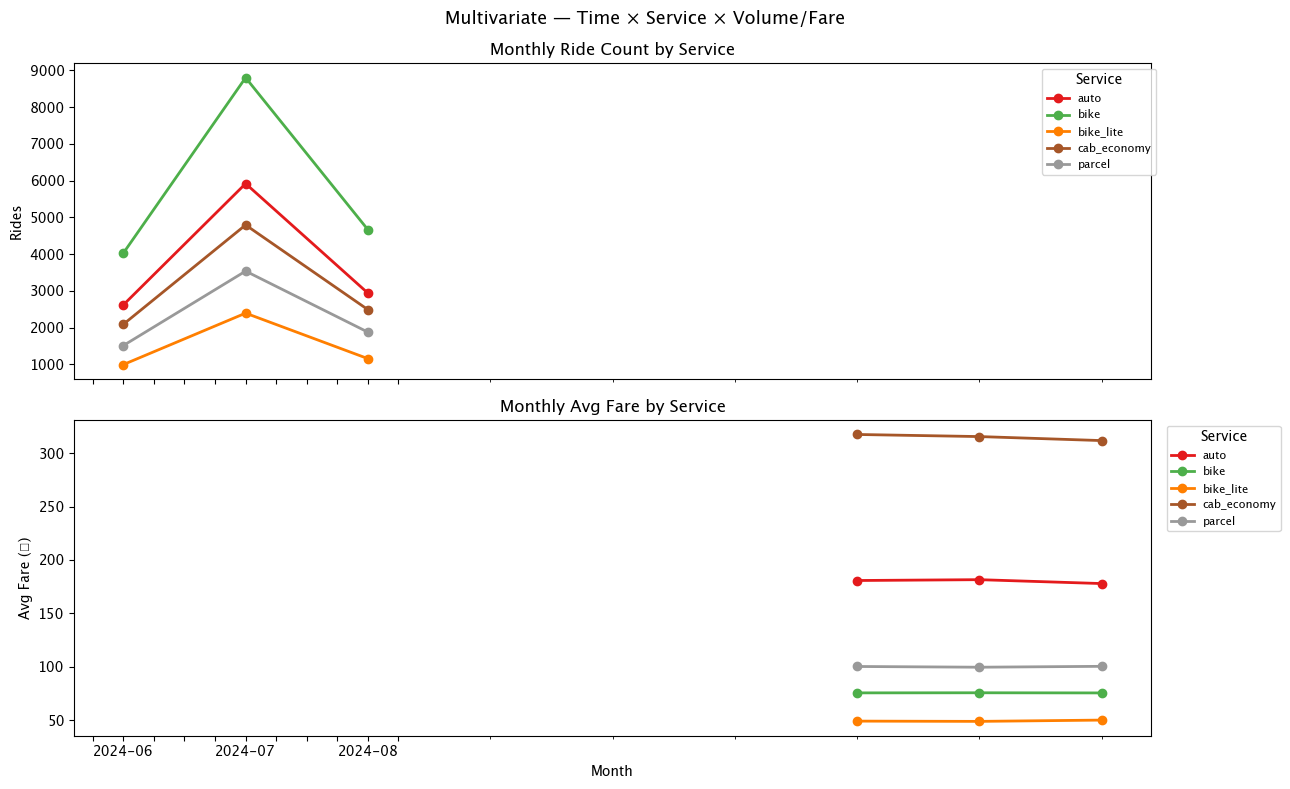

In [33]:
monthly_fare = completed.groupby(['month', 'services'])['ride_charge'].mean().unstack()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# rides over time by service
monthly_service.plot(ax=axes[0], colormap='Set1', linewidth=2, marker='o')
axes[0].set_title('Monthly Ride Count by Service', fontweight='bold')
axes[0].set_ylabel('Rides')
axes[0].legend(title='Service', bbox_to_anchor=(1.01, 1), fontsize=8)

# avg fare over time by service
monthly_fare.plot(ax=axes[1], colormap='Set1', linewidth=2, marker='o')
axes[1].set_title('Monthly Avg Fare by Service', fontweight='bold')
axes[1].set_ylabel('Avg Fare (₹)')
axes[1].set_xlabel('Month')
axes[1].legend(title='Service', bbox_to_anchor=(1.01, 1), fontsize=8)

plt.suptitle('Multivariate — Time × Service × Volume/Fare', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Business Insight — Monthly Trends
Any month with a rise in cancellation rate alongside steady or rising demand signals a driver supply gap —
demand is growing faster than driver availability. These months are the highest-priority windows for
driver acquisition campaigns or incentive boosts.

### M8 — Summary pivot table (3 variables)


In [34]:
pivot2 = completed.pivot_table(
    values=['ride_charge', 'distance', 'avg_speed_kmh'],
    index='services',
    columns='demand_zone',
    aggfunc='mean'
).round(2)

print("=== Avg Metrics: Service × Demand Zone ===")
print(pivot2)

=== Avg Metrics: Service × Demand Zone ===
            avg_speed_kmh                             distance             \
demand_zone   high_demand low_demand medium_demand high_demand low_demand   
services                                                                    
auto                18.66      18.98         18.64        7.42       7.37   
bike                17.96      17.87         17.84        5.66       5.67   
bike_lite           17.50      17.60         17.30        4.40       4.41   
cab_economy         19.52      19.63         19.62       10.60      10.29   
parcel              17.92      17.85         18.01        6.49       6.49   

                          ride_charge                           
demand_zone medium_demand high_demand low_demand medium_demand  
services                                                        
auto                 7.34      181.47     180.09        179.57  
bike                 5.64       75.15      75.79         75.52  
bike_lite      

## PHASE 7 — DOMAIN-SPECIFIC ANALYSIS

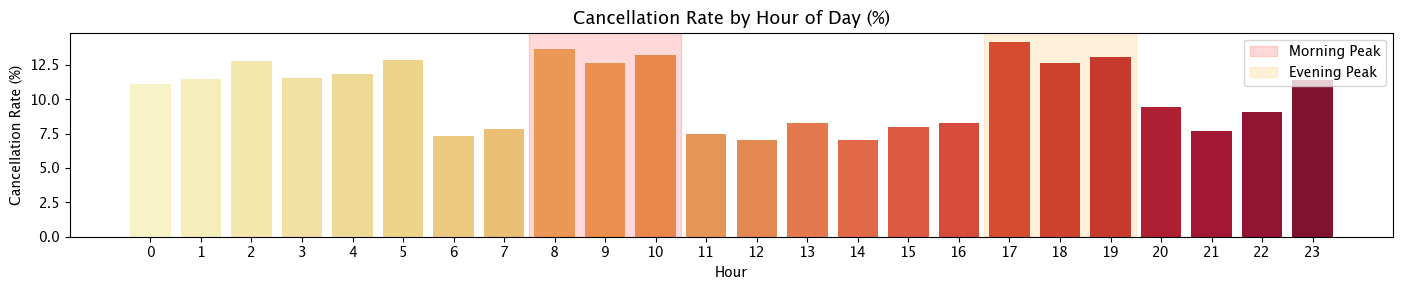

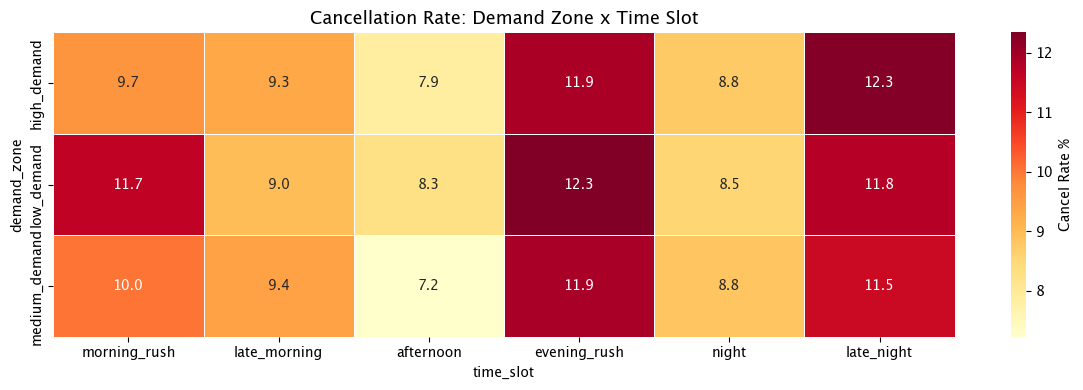

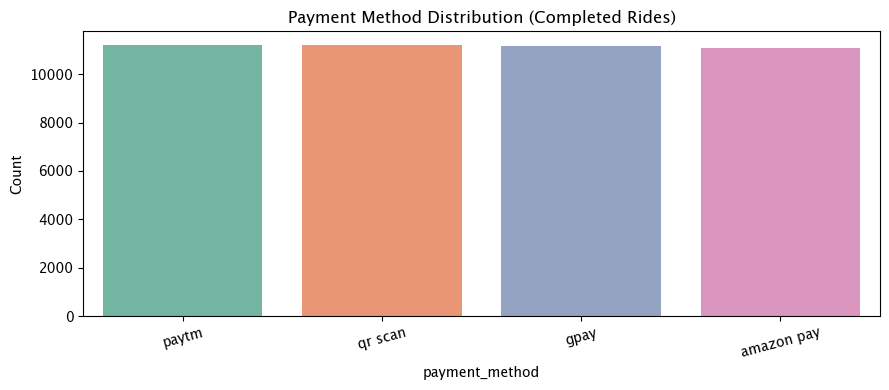

Domain-specific analysis complete.


In [35]:
# PHASE 7 — DOMAIN-SPECIFIC ANALYSIS

# 7.1 Hourly cancellation rate heatmap
hourly_cancel = df.groupby('hour').apply(
    lambda x: (x['ride_status'] == 'cancelled').mean() * 100
).reset_index()
hourly_cancel.columns = ['hour', 'cancel_rate_%']

plt.figure(figsize=(14, 3))
sns.barplot(data=hourly_cancel, x='hour', y='cancel_rate_%', palette='YlOrRd')
plt.axvspan(7.5, 10.5, alpha=0.15, color='red', label='Morning Peak')
plt.axvspan(16.5, 19.5, alpha=0.15, color='orange', label='Evening Peak')
plt.title('Cancellation Rate by Hour of Day (%)', fontweight='bold', fontsize=13)
plt.xlabel('Hour')
plt.ylabel('Cancellation Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

# 7.2 Demand zone x time slot cancellation heatmap
pivot_cancel = df.groupby(['demand_zone', 'time_slot']).apply(
    lambda x: (x['ride_status'] == 'cancelled').mean() * 100
).reset_index(name='cancel_rate_%')

slot_order = ['morning_rush', 'late_morning', 'afternoon', 'evening_rush', 'night', 'late_night']
pivot = pivot_cancel.pivot(index='demand_zone', columns='time_slot', values='cancel_rate_%')
pivot = pivot[[c for c in slot_order if c in pivot.columns]]

plt.figure(figsize=(12, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Cancel Rate %'})
plt.title('Cancellation Rate: Demand Zone x Time Slot', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# 7.3 Payment method distribution (completed rides only)
pay_dist = completed['payment_method'].value_counts()
plt.figure(figsize=(9, 4))
sns.barplot(x=pay_dist.index, y=pay_dist.values, palette='Set2')
plt.title('Payment Method Distribution (Completed Rides)', fontweight='bold')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Domain-specific analysis complete.")